In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

This uses the original data, so you need to download the datasets folder from our GitHub. 

In [2]:
print(os.getcwd())   # it should be in the folder that you have the datasets folder in

/Users/adelaidegray1/Desktop/PIC 16B/project


In [20]:
# copied from sgan/data/trajectories.py

import logging
import math
import torch
from torch.utils.data import Dataset

logger = logging.getLogger(__name__)

def seq_collate(data):
    (obs_seq_list, pred_seq_list, obs_seq_rel_list, pred_seq_rel_list,
     non_linear_ped_list, loss_mask_list) = zip(*data)

    _len = [len(seq) for seq in obs_seq_list]
    cum_start_idx = [0] + np.cumsum(_len).tolist()
    seq_start_end = [[start, end]
                     for start, end in zip(cum_start_idx, cum_start_idx[1:])]

    # Data format: batch, input_size, seq_len
    # LSTM input format: seq_len, batch, input_size
    obs_traj = torch.cat(obs_seq_list, dim=0).permute(2, 0, 1)
    pred_traj = torch.cat(pred_seq_list, dim=0).permute(2, 0, 1)
    obs_traj_rel = torch.cat(obs_seq_rel_list, dim=0).permute(2, 0, 1)
    pred_traj_rel = torch.cat(pred_seq_rel_list, dim=0).permute(2, 0, 1)
    non_linear_ped = torch.cat(non_linear_ped_list)
    loss_mask = torch.cat(loss_mask_list, dim=0)
    seq_start_end = torch.LongTensor(seq_start_end)
    out = [
        obs_traj, pred_traj, obs_traj_rel, pred_traj_rel, non_linear_ped,
        loss_mask, seq_start_end
    ]

    return tuple(out)


def read_file(_path, delim='\t'):
    data = []
    if delim == 'tab':
        delim = '\t'
    elif delim == 'space':
        delim = ' '
    with open(_path, 'r') as f:
        for line in f:
            line = line.strip().split(delim)
            line = [float(i) for i in line]
            data.append(line)
    return np.asarray(data)


def poly_fit(traj, traj_len, threshold):
    """
    Input:
    - traj: Numpy array of shape (2, traj_len)
    - traj_len: Len of trajectory
    - threshold: Minimum error to be considered for non linear traj
    Output:
    - int: 1 -> Non Linear 0-> Linear
    """
    t = np.linspace(0, traj_len - 1, traj_len)
    res_x = np.polyfit(t, traj[0, -traj_len:], 2, full=True)[1]
    res_y = np.polyfit(t, traj[1, -traj_len:], 2, full=True)[1]
    if res_x + res_y >= threshold:
        return 1.0
    else:
        return 0.0


class TrajectoryDataset(Dataset):
    """Dataloder for the Trajectory datasets"""
    def __init__(
        self, data_dir, obs_len=8, pred_len=12, skip=1, threshold=0.002,
        min_ped=1, delim='\t'
    ):
        """
        Args:
        - data_dir: Directory containing dataset files in the format
        <frame_id> <ped_id> <x> <y>
        - obs_len: Number of time-steps in input trajectories
        - pred_len: Number of time-steps in output trajectories
        - skip: Number of frames to skip while making the dataset
        - threshold: Minimum error to be considered for non linear traj
        when using a linear predictor
        - min_ped: Minimum number of pedestrians that should be in a seqeunce
        - delim: Delimiter in the dataset files
        """
        super(TrajectoryDataset, self).__init__()

        self.data_dir = data_dir
        self.obs_len = obs_len
        self.pred_len = pred_len
        self.skip = skip
        self.seq_len = self.obs_len + self.pred_len
        self.delim = delim

        all_files = os.listdir(self.data_dir)
        all_files = [os.path.join(self.data_dir, _path) for _path in all_files]
        num_peds_in_seq = []
        seq_list = []
        seq_list_rel = []
        loss_mask_list = []
        non_linear_ped = []
        for path in all_files:
            data = read_file(path, delim)
            frames = np.unique(data[:, 0]).tolist()
            frame_data = []
            for frame in frames:
                frame_data.append(data[frame == data[:, 0], :])
            num_sequences = int(
                math.ceil((len(frames) - self.seq_len + 1) / skip))

            for idx in range(0, num_sequences * self.skip + 1, skip):
                curr_seq_data = np.concatenate(
                    frame_data[idx:idx + self.seq_len], axis=0)
                peds_in_curr_seq = np.unique(curr_seq_data[:, 1])
                curr_seq_rel = np.zeros((len(peds_in_curr_seq), 2,
                                         self.seq_len))
                curr_seq = np.zeros((len(peds_in_curr_seq), 2, self.seq_len))
                curr_loss_mask = np.zeros((len(peds_in_curr_seq),
                                           self.seq_len))
                num_peds_considered = 0
                _non_linear_ped = []
                for _, ped_id in enumerate(peds_in_curr_seq):
                    curr_ped_seq = curr_seq_data[curr_seq_data[:, 1] ==
                                                 ped_id, :]
                    curr_ped_seq = np.around(curr_ped_seq, decimals=4)
                    pad_front = frames.index(curr_ped_seq[0, 0]) - idx
                    pad_end = frames.index(curr_ped_seq[-1, 0]) - idx + 1
                    if pad_end - pad_front != self.seq_len:
                        continue
                    curr_ped_seq = np.transpose(curr_ped_seq[:, 2:])
                    curr_ped_seq = curr_ped_seq
                    # Make coordinates relative
                    rel_curr_ped_seq = np.zeros(curr_ped_seq.shape)
                    rel_curr_ped_seq[:, 1:] = \
                        curr_ped_seq[:, 1:] - curr_ped_seq[:, :-1]
                    _idx = num_peds_considered
                    curr_seq[_idx, :, pad_front:pad_end] = curr_ped_seq
                    curr_seq_rel[_idx, :, pad_front:pad_end] = rel_curr_ped_seq
                    # Linear vs Non-Linear Trajectory
                    _non_linear_ped.append(
                        poly_fit(curr_ped_seq, pred_len, threshold))
                    curr_loss_mask[_idx, pad_front:pad_end] = 1
                    num_peds_considered += 1

                if num_peds_considered > min_ped:
                    non_linear_ped += _non_linear_ped
                    num_peds_in_seq.append(num_peds_considered)
                    loss_mask_list.append(curr_loss_mask[:num_peds_considered])
                    seq_list.append(curr_seq[:num_peds_considered])
                    seq_list_rel.append(curr_seq_rel[:num_peds_considered])

        self.num_seq = len(seq_list)
        seq_list = np.concatenate(seq_list, axis=0)
        seq_list_rel = np.concatenate(seq_list_rel, axis=0)
        loss_mask_list = np.concatenate(loss_mask_list, axis=0)
        non_linear_ped = np.asarray(non_linear_ped)

        # Convert numpy -> Torch Tensor
        self.obs_traj = torch.from_numpy(
            seq_list[:, :, :self.obs_len]).type(torch.float)
        self.pred_traj = torch.from_numpy(
            seq_list[:, :, self.obs_len:]).type(torch.float)
        self.obs_traj_rel = torch.from_numpy(
            seq_list_rel[:, :, :self.obs_len]).type(torch.float)
        self.pred_traj_rel = torch.from_numpy(
            seq_list_rel[:, :, self.obs_len:]).type(torch.float)
        self.loss_mask = torch.from_numpy(loss_mask_list).type(torch.float)
        self.non_linear_ped = torch.from_numpy(non_linear_ped).type(torch.float)
        cum_start_idx = [0] + np.cumsum(num_peds_in_seq).tolist()
        self.seq_start_end = [
            (start, end)
            for start, end in zip(cum_start_idx, cum_start_idx[1:])
        ]

    def __len__(self):
        return self.num_seq

    def __getitem__(self, index):
        start, end = self.seq_start_end[index]
        out = [
            self.obs_traj[start:end, :], self.pred_traj[start:end, :],
            self.obs_traj_rel[start:end, :], self.pred_traj_rel[start:end, :],
            self.non_linear_ped[start:end], self.loss_mask[start:end, :]
        ]
        return out

In [21]:
# load the training dataset
dset = TrajectoryDataset(
    data_dir="datasets/eth/train"
)

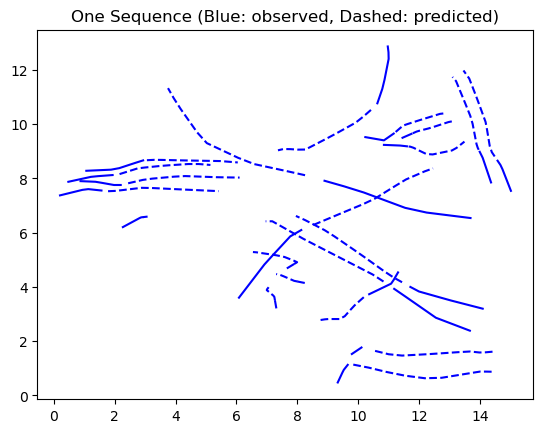

In [22]:
# this is to print the first sequence of trajectories in dset
obs_traj, pred_traj = dset[0][0], dset[0][1]
# shape of each trajectory: (number of people, 2, length of trajectory)

for i in range(obs_traj.shape[0]):      # iterate through each person
    plt.plot(obs_traj[i,0,:], obs_traj[i,1,:], 'blue')     # observed
    plt.plot(pred_traj[i,0,:], pred_traj[i,1,:], 'blue', linestyle='--')    # predicted

plt.title('One Sequence (Blue: observed, Dashed: predicted)')
plt.show()

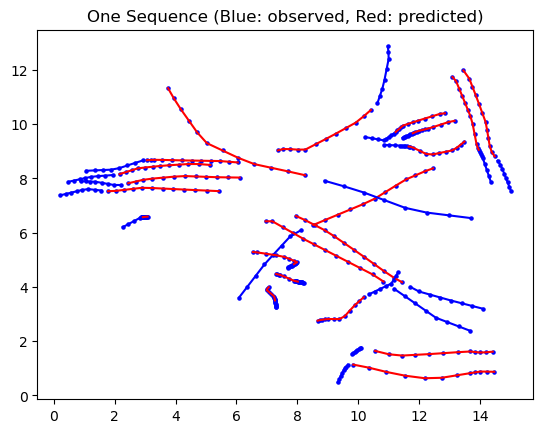

In [23]:
# same as above graph but with dots at each time point
for i in range(obs_traj.shape[0]):      
    plt.plot(obs_traj[i,0,:], obs_traj[i,1,:], 'blue')     # observed
    plt.plot(pred_traj[i,0,:], pred_traj[i,1,:], 'red')    # predicted
    plt.scatter(obs_traj[i,0,:], obs_traj[i,1,:], s=5, color='blue')
    plt.scatter(pred_traj[i,0,:], pred_traj[i,1,:], s=5, color='blue')

plt.title('One Sequence (Blue: observed, Red: predicted)')
plt.show()

In [24]:
# create a dataframe from dset

rows = []

# loop through each sequence and add the data to the list of rows
for seq_id in range(len(dset)):
    obs_traj, pred_traj = dset[seq_id][0], dset[seq_id][1]

    num_people = obs_traj.shape[0]
    obs_len = obs_traj.shape[2]
    pred_len = pred_traj.shape[2]

    for person in range(num_people):

        for t in range(obs_len):
            x = obs_traj[person, 0, t].item()    # .item converts it to a float
            y = obs_traj[person, 1, t].item()
            rows.append([seq_id, person, t, x, y, "obs"])

        for t in range(pred_len):
            x = pred_traj[person, 0, t].item()
            y = pred_traj[person, 1, t].item()
            rows.append([seq_id, person, t + obs_len, x, y, "pred"])      # add on observed time

df = pd.DataFrame(rows, columns=['sequence_id', 'person_id', 't', 'x', 'y', 'type'])

df

,sequence_id,person_id,t,x,y,type
0,0,0,0,6.0824,3.6038,obs
1,0,0,1,6.3609,4.0119,obs
2,0,0,2,6.6391,4.4197,obs
3,0,0,3,6.9176,4.8278,obs
4,0,0,4,7.1998,5.1775,obs
...,...,...,...,...,...,...
596175,2784,1,15,14.7140,7.4648,pred
596176,2784,1,16,14.8218,7.1970,pred
596177,2784,1,17,14.9298,6.9292,pred
596178,2784,1,18,15.0375,6.6615,pred


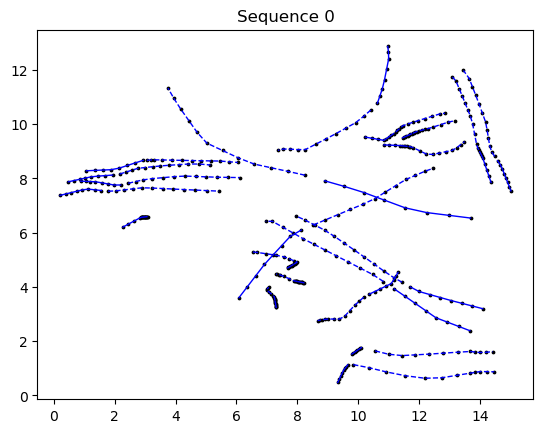

In [25]:
# this plots the same sequence as we plotted from the dset

seq = df[df['sequence_id'] == 0]

for _, group in seq.groupby('person_id'):
    obs = group[group['type'] == 'obs']
    pred = group[group['type'] == 'pred']
    
    plt.plot(obs['x'], obs['y'], 'blue', linewidth=1)
    plt.plot(pred['x'], pred['y'], 'blue', linewidth=1, linestyle = '--')
    plt.scatter(obs['x'], obs['y'], s=3, color='black')
    plt.scatter(pred['x'], pred['y'], s=3, color='black')

plt.title(f"Sequence 0")
plt.show()

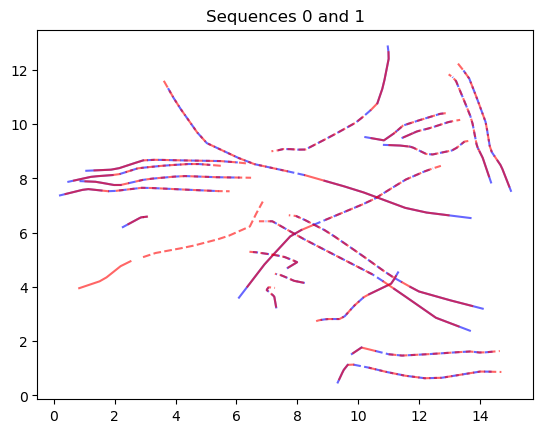

In [26]:
# notice: sequences close in rows close together have overlapping trajectories 
# this should be ok for training models, it just means there is a lot of repeated data

i=0
seq = df[df['sequence_id'] == i]

for _, group in seq.groupby('person_id'):
    obs = group[group['type'] == 'obs']
    pred = group[group['type'] == 'pred']
    
    plt.plot(obs['x'], obs['y'], 'blue', alpha=.6)
    plt.plot(pred['x'], pred['y'], 'blue', linestyle = '--', alpha=.6)

i=1
seq = df[df['sequence_id'] == i]

for _, group in seq.groupby('person_id'):
    obs = group[group['type'] == 'obs']
    pred = group[group['type'] == 'pred']
    
    plt.plot(obs['x'], obs['y'], 'red', alpha=.6)
    plt.plot(pred['x'], pred['y'], 'red', linestyle = '--', alpha=.6)

plt.title(f"Sequences 0 and 1")
plt.show()

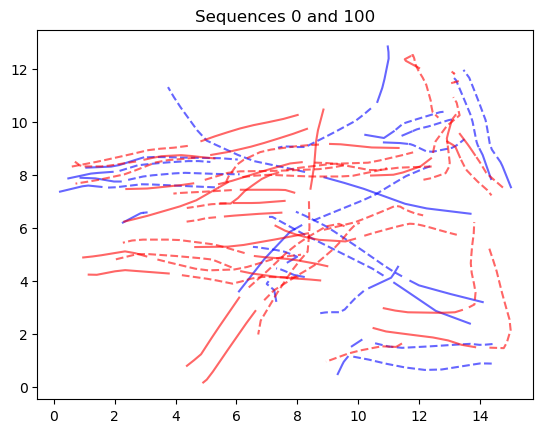

In [27]:
# sequences farther apart have very different trajectories

i=0
seq = df[df['sequence_id'] == i]

for _, group in seq.groupby('person_id'):
    obs = group[group['type'] == 'obs']
    pred = group[group['type'] == 'pred']
    
    plt.plot(obs['x'], obs['y'], 'blue', alpha=.6)
    plt.plot(pred['x'], pred['y'], 'blue', linestyle = '--', alpha=.6)

i=100
seq = df[df['sequence_id'] == i]

for _, group in seq.groupby('person_id'):
    obs = group[group['type'] == 'obs']
    pred = group[group['type'] == 'pred']
    
    plt.plot(obs['x'], obs['y'], 'red', alpha=.6)
    plt.plot(pred['x'], pred['y'], 'red', linestyle = '--', alpha=.6)

plt.title(f"Sequences 0 and 100")
plt.show()

### description of df columns

`sequence_id`: unique for each walking trajectory sequence. *int*

`person_id`: unique for each person in each sequence. *int*
- note: it is specific to each sequence. 

`t`: the time index. *int, 0 to 19*
- $0-7$: observed trajectories
- $8-19$: predicted trajectories

`x`, `y`: the positions. *float*

`type`: "obs" or "pred"

### I added the following columns for EDA

`vx`, `vy`: the directional speeds. *float*

`speed`: speed of the movement. *float*

`acceleration`: acceleration of the movement. *float*

** Note: speed and acceleration are both NaN for the first values bc it uses diff(). If that's an issue they could maybe be replaced with None or 0

`angle`: the direction of movement. *float, $-\pi$ to $\pi$*
- $0$: moving right
- $\frac{\pi}{2}$: moving upwards
- $\pi$: moving left
- $-\frac{\pi}{2}$: moving downwards

`angle_change`: the change of movement. *float, $-\pi$ to $\pi$*
- $0$: going straight
- larger number: sharper turn
- ~$\pi,-\pi$: turning around

`people_per_seq`: the number of people/trajectories in each sequence. *int*

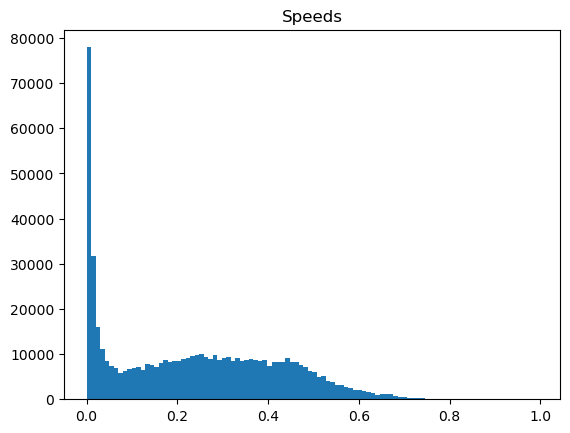

In [11]:
df = df.sort_values(['sequence_id', 'person_id', 't'])

df['vx'] = df.groupby(['sequence_id','person_id'])['x'].diff()
df['vy'] = df.groupby(['sequence_id','person_id'])['y'].diff()

df['speed'] = (df['vx']**2 + df['vy']**2)**0.5

plt.hist(df['speed'],bins=100)
plt.title("Speeds")
plt.show()

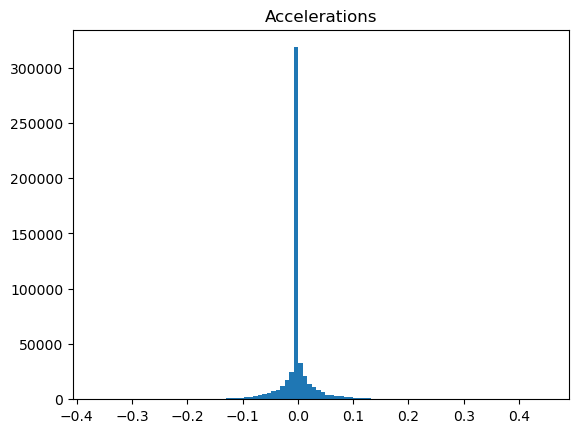

In [12]:
df['acceleration'] = df.groupby(['sequence_id', 'person_id'])['speed'].diff()

plt.hist(df['acceleration'],bins=100)
#plt.ylim(0, 5000)       # to visualize the non-zero values better
plt.title("Accelerations")
plt.show()

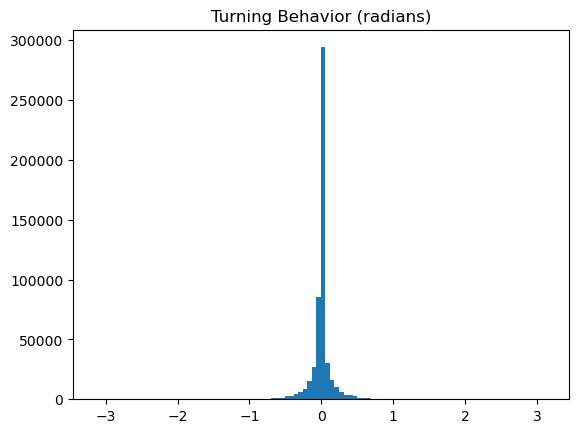

In [13]:
df['angle'] = np.arctan2(df['vy'], df['vx'])
df['angle_change'] = df.groupby(['sequence_id','person_id'])['angle'].diff()
# normalize angle differences (make sure its between -pi and pi)
df['angle_change'] = (df['angle_change'] + np.pi) % (2 * np.pi) - np.pi

plt.hist(df['angle_change'], bins=100)
plt.title("Turning Behavior (radians)")
#plt.ylim(0, 5000)       # to visualize the non-zero values better
plt.show()

# lots of turns near 0, so more straight behavior, less turning

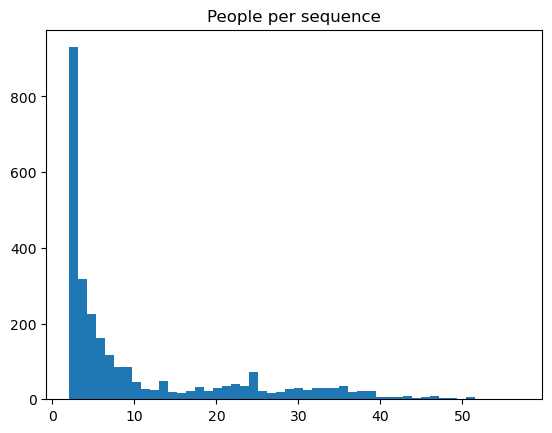

In [14]:
df['people_per_seq'] = df.groupby('sequence_id')['person_id'].transform('nunique')

people_per_seq = df.groupby('sequence_id')['person_id'].nunique()

plt.hist(people_per_seq, bins=50)
plt.title("People per sequence")
#plt.xlim(0,10) # visualize the smaller values
plt.show()

Text(0.5, 1.0, 'Average Speed vs. People per Sequence')

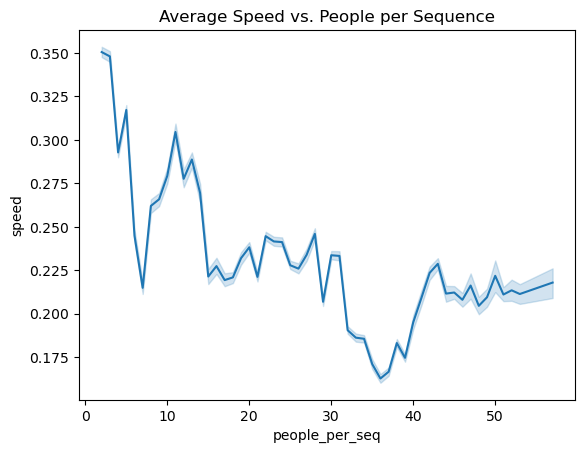

In [15]:
sns.lineplot(df, x='people_per_seq', y='speed')
plt.title('Average Speed vs. People per Sequence')

Text(0.5, 1.0, 'Average Angle Change vs. People per Sequence')

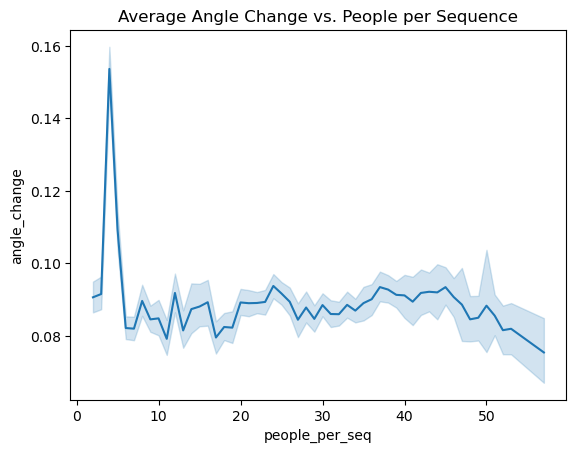

In [16]:
sns.lineplot(df, x='people_per_seq', y=np.abs(df['angle_change']))
plt.title('Average Angle Change vs. People per Sequence')

Text(0.5, 1.0, 'Average Acceleration vs. People per Sequence')

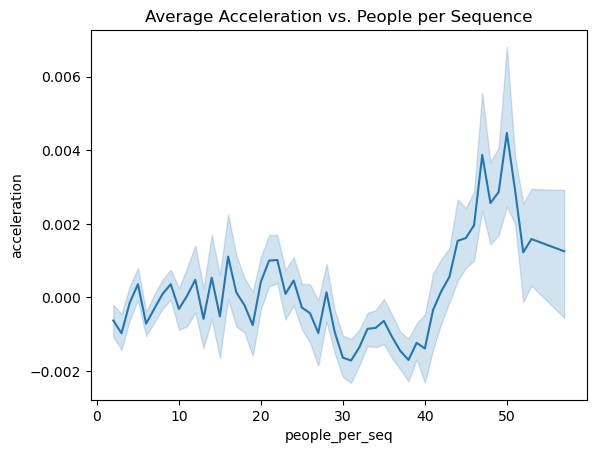

In [17]:
sns.lineplot(df, x='people_per_seq', y='acceleration')
plt.title('Average Acceleration vs. People per Sequence')

In [18]:
df

,sequence_id,person_id,t,x,y,type,vx,vy,speed,acceleration,angle,angle_change,people_per_seq
0,0,0,0,6.0824,3.6038,obs,NaN,NaN,NaN,NaN,NaN,NaN,21
1,0,0,1,6.3609,4.0119,obs,0.278500,0.4081,0.494073,NaN,0.971959,NaN,21
2,0,0,2,6.6391,4.4197,obs,0.278200,0.4078,0.493656,-0.000417,0.972119,0.000160,21
3,0,0,3,6.9176,4.8278,obs,0.278500,0.4081,0.494072,0.000416,0.971959,-0.000160,21
4,0,0,4,7.1998,5.1775,obs,0.282200,0.3497,0.449363,-0.044710,0.891816,-0.080143,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
596175,2784,1,15,14.7140,7.4648,pred,0.107699,-0.2678,0.288645,0.022968,-1.188427,0.316453,2
596176,2784,1,16,14.8218,7.1970,pred,0.107800,-0.2678,0.288683,0.000037,-1.188101,0.000326,2
596177,2784,1,17,14.9298,6.9292,pred,0.108000,-0.2678,0.288757,0.000074,-1.187461,0.000640,2
596178,2784,1,18,15.0375,6.6615,pred,0.107700,-0.2677,0.288553,-0.000204,-1.188294,-0.000833,2
